# pipeline de dados — pipeline de dados: split em 3 etapas, anti-vazamento e pré-processamento

Implementa o procedimento de particionamento exigido pelo enunciado:

1. Separar o dataset em duas classes (`Churn=Yes` / `Churn=No`).
2. Dividir cada classe em 50% treino / 25% validação / 25% teste.
3. Reamostrar (com repetição) a classe minoritária **dentro de treino e
   validação**, para igualar o tamanho da classe majoritária naquela
   partição. **O teste nunca é reamostrado** — decisão de design explícita
   (ver `src/churn_telecom/data.py`): reamostrar o teste duplicaria a mesma
   linha em treino e teste via cópia, o que é uma forma de vazamento.
4. Recombinar e embaralhar cada partição.

Esta etapa não treina nenhum modelo ainda — o objetivo é provar que o
pipeline de dados está correto antes de gastar tempo de treino em cima dele.


In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from churn_telecom.data import load_raw, split_three_stage, assert_sem_vazamento
from churn_telecom.features import Preprocessor, NUMERIC_COLS, _to_total_charges_float

sns.set_theme(style="whitegrid")
df = load_raw(ROOT / "data")
df.shape


(7043, 21)

## 1. Split de 3 etapas

In [2]:
split = split_three_stage(df, seed=0)
print(f"train: {len(split.train_idx)} linhas | val: {len(split.val_idx)} | test: {len(split.test_idx)}")


train: 5174 linhas | val: 2588 | test: 1761


## 2. Teste de ausência de vazamento

Confere que nenhuma linha **original** (antes da reamostragem) aparece em
mais de uma partição — a reamostragem cria cópias da mesma linha dentro da
*mesma* partição (treino ou validação), o que é esperado e não é vazamento.

In [3]:
assert_sem_vazamento(split)
print("OK — nenhuma linha original aparece em mais de uma partição.")


OK — nenhuma linha original aparece em mais de uma partição.


## 3. Tamanhos e proporção de classe por partição

In [4]:
def resume_particao(nome, idx):
    sub = df.iloc[idx]
    return {
        "partição": nome,
        "n_linhas": len(idx),
        "n_linhas_únicas": len(set(idx.tolist())),
        "prop_churn_yes": round(float((sub["Churn"] == "Yes").mean()), 4),
    }

resumo = pd.DataFrame([
    resume_particao("train (com oversampling)", split.train_idx),
    resume_particao("val (com oversampling)", split.val_idx),
    resume_particao("test (sempre real)", split.test_idx),
    resume_particao("train (sem oversampling)", split.train_no_oversample_idx),
    resume_particao("val (sem oversampling)", split.val_no_oversample_idx),
])
resumo


,partição,n_linhas,n_linhas_únicas,prop_churn_yes
0,train (com oversampling),5174,3461,0.5000
1,val (com oversampling),2588,1726,0.5000
2,test (sempre real),1761,1761,0.2658
3,train (sem oversampling),3521,3521,0.2653
4,val (sem oversampling),1761,1761,0.2652


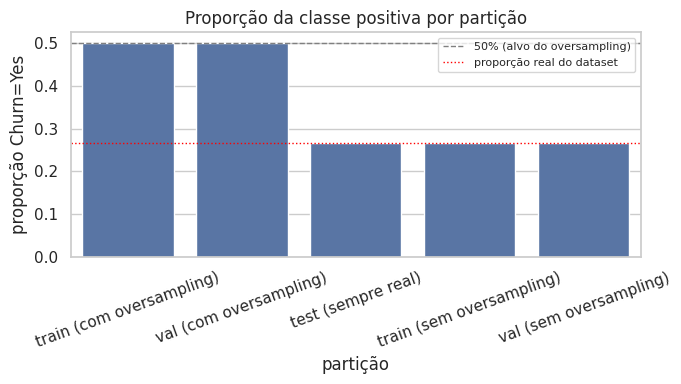

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=resumo, x="partição", y="prop_churn_yes", ax=ax)
ax.axhline(0.5, ls="--", color="gray", lw=1, label="50% (alvo do oversampling)")
ax.axhline(df["Churn"].eq("Yes").mean(), ls=":", color="red", lw=1, label="proporção real do dataset")
ax.set_ylabel("proporção Churn=Yes")
ax.set_title("Proporção da classe positiva por partição")
ax.tick_params(axis="x", rotation=20)
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(ROOT / "reports/figures/pipeline_proporcao_por_particao.png", dpi=120)
plt.show()


Treino e validação ficam em ~50/50 por causa da reamostragem; o teste
preserva a proporção real do dataset (~26.5% positiva) — exatamente o
comportamento esperado.

## 4. Pré-processamento (ajustado só no treino)

O `Preprocessor` faz: imputação de `TotalCharges` (clientes `tenure=0` →
0, valor logicamente correto, não estimado), encoding binário/one-hot, e
normalização z-score das numéricas — **tudo ajustado (`fit`) só com o
treino**, depois aplicado (`transform`) em val/teste.

In [6]:
df_train = df.iloc[split.train_idx]
df_val = df.iloc[split.val_idx]
df_test = df.iloc[split.test_idx]

prep = Preprocessor().fit(df_train)
X_train, cols = prep.transform(df_train)
X_val, _ = prep.transform(df_val)
X_test, _ = prep.transform(df_test)
y_train = prep.transform_target(df_train)
y_val = prep.transform_target(df_val)
y_test = prep.transform_target(df_test)

print(f"X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}")
print(f"n_features após encoding: {len(cols)}")


X_train: (5174, 40) | X_val: (2588, 40) | X_test: (1761, 40)
n_features após encoding: 40


## 5. Prova de que o scaler não viu validação/teste

Compara a média usada pelo scaler (ajustada só no treino) contra a média do
**dataset inteiro** — se fossem iguais, seria sinal de que o `fit` vazou
informação de fora do treino.

In [7]:
df_full_numeric = df[NUMERIC_COLS].copy()
df_full_numeric["TotalCharges"] = _to_total_charges_float(df_full_numeric["TotalCharges"]).fillna(0)
mean_full = df_full_numeric.mean()

comparacao = pd.DataFrame({
    "média (scaler, só treino)": prep.numeric_mean_,
    "média (dataset inteiro)": mean_full,
})
comparacao["diferença"] = (comparacao["média (scaler, só treino)"] - comparacao["média (dataset inteiro)"]).abs()
comparacao


,"média (scaler, só treino)",média (dataset inteiro),diferença
tenure,27.701198,32.371149,4.669950
MonthlyCharges,68.635263,64.761692,3.873570
TotalCharges,2053.735524,2279.734304,225.998780
SeniorCitizen,0.190182,0.162147,0.028035


In [8]:
assert comparacao["diferença"].sum() > 0, "scaler bate exatamente com o dataset inteiro — suspeita de vazamento!"
print(f"diferença total: {comparacao['diferença'].sum():.4f} (> 0 confirma que não houve vazamento)")


diferença total: 234.5703 (> 0 confirma que não houve vazamento)


## 6. Proporção do alvo pós-encoding (confirmação final)

In [9]:
print(f"y_train: {y_train.mean():.4f} (esperado ~0.5000)")
print(f"y_val:   {y_val.mean():.4f} (esperado ~0.5000)")
print(f"y_test:  {y_test.mean():.4f} (esperado ~{df['Churn'].eq('Yes').mean():.4f}, proporção real)")


y_train: 0.5000 (esperado ~0.5000)
y_val:   0.5000 (esperado ~0.5000)
y_test:  0.2658 (esperado ~0.2654, proporção real)


## 7. Resumo e próximos passos

- Split de 3 etapas implementado e validado: sem vazamento de linha
  original entre partições, oversampling restrito a treino/validação,
  teste sempre com a distribuição real.
- Pré-processamento com disciplina anti-vazamento confirmada
  numericamente (scaler não bate com o dataset inteiro).
- 40 features após encoding (numéricas normalizadas + binárias 0/1 +
  one-hot das categóricas de 3+ níveis).
- Próximo passo: baseline MLP (1 camada, 10 unidades) + Gradient Boosting,
  com a métrica KS validada (`src/churn_telecom/metrics.py`) como critério
  principal de avaliação.


In [10]:
out_tables = ROOT / "reports" / "tables"
out_tables.mkdir(parents=True, exist_ok=True)
resumo.to_csv(out_tables / "pipeline_resumo_particoes.csv", index=False)
pd.DataFrame({"coluna_apos_encoding": cols}).to_csv(out_tables / "pipeline_colunas_apos_encoding.csv", index=False)
print("tabelas salvas em reports/tables/")


tabelas salvas em reports/tables/
